In [1]:
import pandas as pd

## 1. Data Understanding

In [2]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


    . DropUn-necessary Columns:

In [3]:
df.drop(["bmi", "charges"], axis= 1, inplace =True)
df.head()

,age,sex,children,smoker,region
0,19,female,0,yes,southwest
1,18,male,1,no,southeast
2,28,male,3,no,southeast
3,33,male,0,no,northwest
4,32,male,0,no,northwest


## 2. Check for Datatypes
    . Display Datatypes

In [4]:
dtypes = df.dtypes
n_uniq = df.nunique()
pd.DataFrame({"Dtypes": dtypes, "Num_Uniqe": n_uniq}).T     

,age,sex,children,smoker,region
Dtypes,int64,str,int64,str,str
Num_Uniqe,47,2,6,2,4


    . Change In-correct Datatypes

In [5]:
cols = ["sex", "smoker", "region"]
df[cols] = df[cols].astype('category')
pd.DataFrame(df.dtypes).T

,age,sex,children,smoker,region
0,int64,category,int64,category,category


## 3. Handle Null Values

In [6]:
null = df.isnull().sum()
ratio = null / df. shape[0]
pd.DataFrame({"Null_sum": null, "Ratio": ratio}).T

,age,sex,children,smoker,region
Null_sum,0.0,0.0,0.0,0.0,0.0
Ratio,0.0,0.0,0.0,0.0,0.0


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

## 4. Handle Outliers
    . Check Outliers

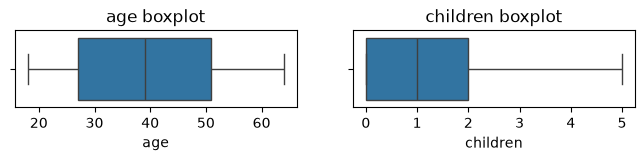

In [8]:
num_cols = df.select_dtypes("number").columns
plt.figure(figsize=(8, 1))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    sns.boxplot(df[col], orient= "h")
    plt.title(f"{col} boxplot")


## 5.Remove Duplicates
    . Check

In [9]:
df.duplicated().sum()

np.int64(352)

    . Remove

In [10]:
df.drop_duplicates(inplace=True)

    . Check After Removing

In [11]:
df.duplicated().sum()

np.int64(0)

## 6.Visualization
    Numerical Data Distribution Graphs:

    . Histogram

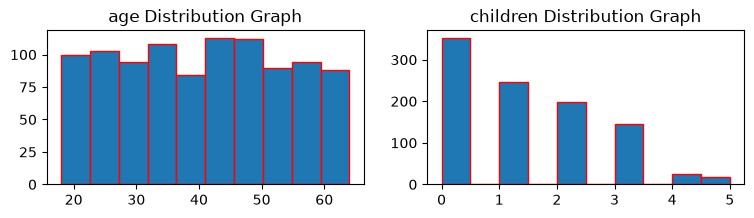

In [12]:
num_cols = df.select_dtypes("number").columns
plt.figure(figsize=(9, 2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    plt.hist(df[col], edgecolor="red")
    plt.title(f"{col} Distribution Graph")
plt.show()

    . KDE Plot

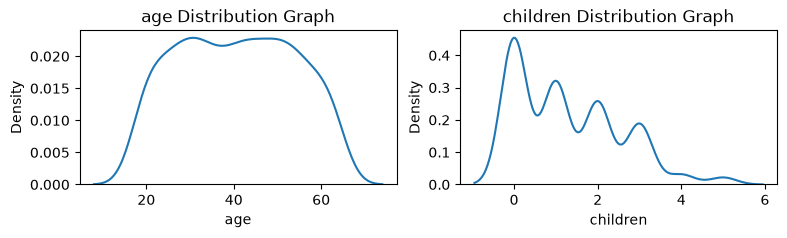

In [13]:
num_cols = df.select_dtypes("number").columns
plt.figure(figsize=(9, 2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} Distribution Graph")
plt.show()

    Categorical Data Distribution Graphs:

    . Count Plot

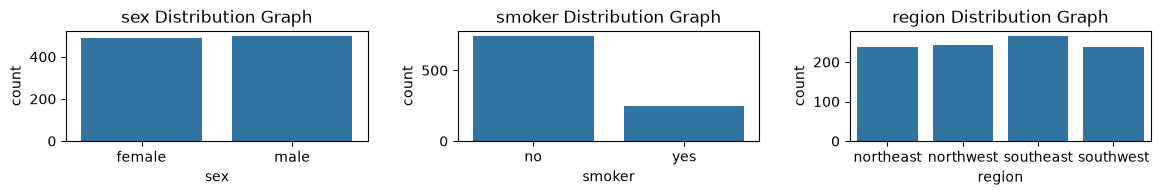

In [14]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(14, 4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i+1)
    sns.countplot(x=col, data=df)
    plt.title(f"{col} Distribution Graph")
plt.subplots_adjust(hspace =.8, wspace =.3)
plt.show()

    . Pie Plot

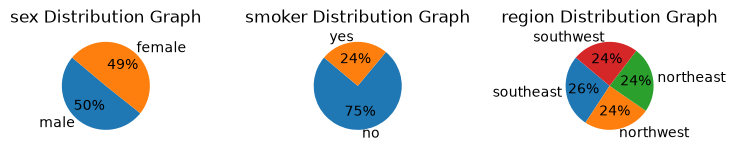

In [15]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(9,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories = unique.index
    plt.pie(count, labels = categories, startangle=140, autopct='%1.1d%%')
    plt.title(f"{col} Distribution Graph")
plt.subplots_adjust(hspace =.8, wspace =.3)
plt.show()

    Relationship Graphs:
    Numerical/Numerical Relationship
    . Scatter Plot

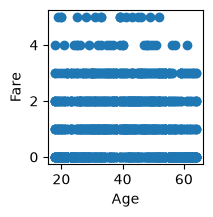

In [18]:
plt.figure(figsize=(2, 2))
plt.scatter(df["age"], df["children"])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

    . Pair Plot

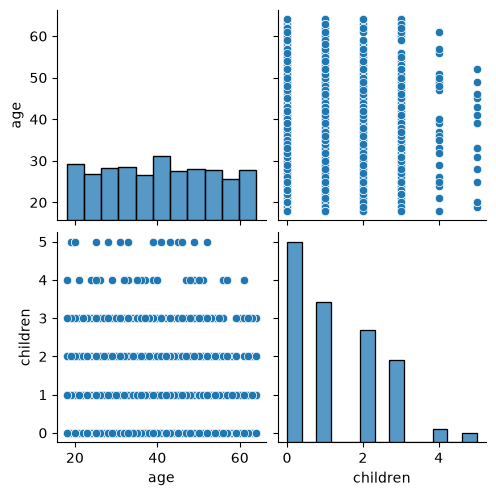

In [19]:
sns.pairplot(df)

    . Line Plot

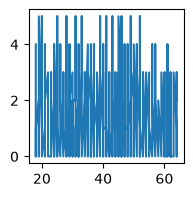

In [20]:
sorted_df = df.sort_values(by="age")
plt.figure(figsize=(2, 2))
plt.plot(sorted_df["age"], sorted_df["children"])
plt.show()

    . Heat Map

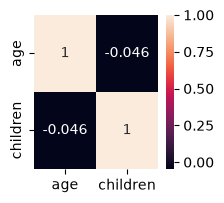

In [24]:
corr = df.select_dtypes(include="number").corr()
plt.figure(figsize=(2, 2))
sns.heatmap(corr, annot=True)
plt.show()

    Numerical/Categorical Relationship
    . Bar Plot

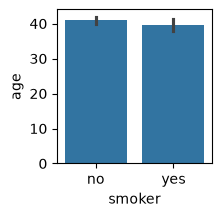

In [28]:
plt.figure(figsize=(2, 2))
sns.barplot(x="smoker", y="age", data=df)
plt.show()

    . HeatMap

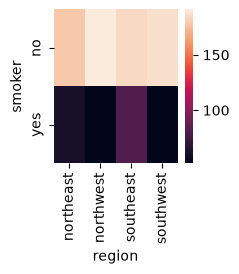

In [29]:
plt.figure(figsize=(2,2))
agg = df.pivot_table(index="smoker", columns="region", values="age", aggfunc=len)
sns.heatmap(agg)
plt.show()

## 7. Data Splitting

In [32]:
X = df.drop("region", axis=1)
y = df[["region"]]

In [34]:
X

,age,sex,children,smoker
0,19,female,0,yes
1,18,male,1,no
2,28,male,3,no
3,33,male,0,no
4,32,male,0,no
...,...,...,...,...
1329,52,male,2,no
1330,57,female,2,no
1332,52,female,3,no
1333,50,male,3,no


In [35]:
y

,region
0,southwest
1,southeast
2,southeast
3,northwest
4,northwest
...,...
1329,southwest
1330,southeast
1332,southwest
1333,northwest
